In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

%matplotlib inline

c:\Users\comp\OneDrive\Desktop\LABS\Credit Card loan ML project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\comp\AppData\Local\Temp\ipykernel_6984\3971771572.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
import sys
sys.path.append('..')
from src.db_connect import get_db_engine
from sqlalchemy import text

engine = get_db_engine()

try:
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
        print("Connection successful!")
except Exception as e:
    print(f"Connection failed: {e}")

Connection successful!


In [4]:
df = pd.read_sql("SELECT * FROM creditcarddb.credit_card_info", con= engine)

df.head()



,id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
# THE NULL VALUES IS SAVE AS 0 IN THE DATABASE SO WE NEED TO REPLACE IT WITH NAN
df["MonthlyIncome"] = df["MonthlyIncome"].replace(0, np.nan)
df.isnull().sum()

id                                          0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           31365
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                          0
dtype: int64

In [6]:
df.describe()

,id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.186350e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.762092e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.446194e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.500000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366507,5.437000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.300000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## Key Findings from df.describe()

### RevolvingUtilizationOfUnsecuredLines
- Max value is 50,708 — should be between 0 and 1 as it is a percentage
- Extreme outliers present — needs capping during preprocessing

### Age
- Min value is 0 — impossible age, confirmed bad data entry
- Max value is 109 — suspicious but possible, needs investigation
- Mean age is 52 years — middle aged borrower base

### NumberOfTimes90DaysLate
- Max value is 98 — confirms suspicious placeholder values found in SQL EDA
- Same issue exists in 30-59 and 60-89 day late columns
- 269 rows affected — will be removed during preprocessing

### DebtRatio
- Max value is 329,664 — extremely impossible outlier
- Normal range should be 0 to 1
- 35,137 rows above 1 confirmed from SQL EDA
- Needs aggressive capping or removal during preprocessing

### MonthlyIncome
- Max value is 3,008,750 — extreme outlier present
- 31,365 missing values confirmed — stored as 0 in database
- Successfully replaced with NaN in this notebook

### SeriousDlqin2yrs (Target Column)
- Mean is 0.066 — confirms 6.7% default rate found in SQL EDA
- Heavily imbalanced dataset — SMOTE required in Phase 3

In [7]:
Profile = ProfileReport(df, title = "Credit Card Data Profilling Report", explorative = True)

Profile.to_file("../data/eda_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 25.31it/s]


## Automated EDA Report (ydata-profiling)

### Why This Report
Manual EDA in SQL and Pandas catches specific issues we look for.
ydata-profiling automatically scans every column and generates a complete
HTML report covering distributions, correlations, missing values, and outliers.
This serves as a professional documentation artifact for the portfolio.

### What This Report Contains
- Overview: dataset shape, missing cells, duplicate rows, memory size
- Variables: distribution, statistics, and alerts for each column
- Interactions: relationship between any two columns visually
- Correlations: which columns are most related to each other
- Missing values: visual map of where NaN values exist
- Sample: first and last rows of the dataset

### Key Stats Confirmed by Report
- 150,000 observations across 12 variables
- 31,365 missing cells (1.7%) — all in MonthlyIncome column
- 0 duplicate rows — data integrity confirmed
- 11 numeric columns, 1 categorical
- 18 alerts detected — outliers, skewed distributions, high correlations

## Visual EDA

### Chart 1 — Class Imbalance
Visualizing the distribution of the target column SeriousDlqin2yrs.
A heavily imbalanced dataset requires special handling during model training.

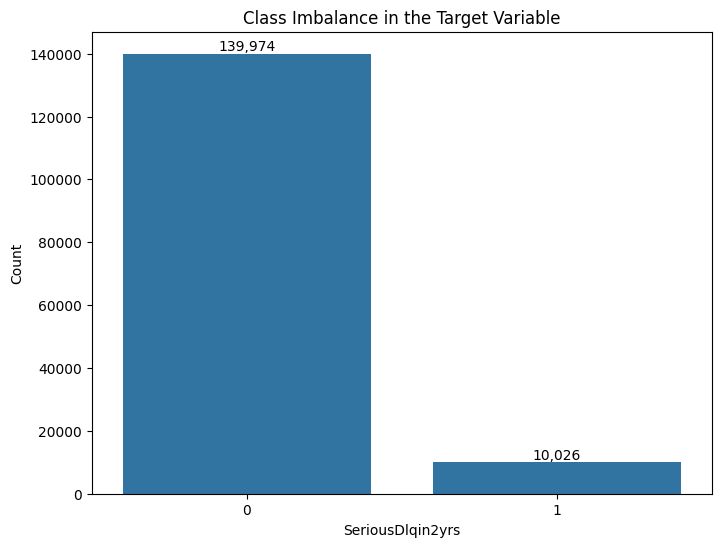

In [9]:
# Checking the Class Imbalance with the help of matplotlib 
plt.figure(figsize=(8,6))
sns.countplot(x="SeriousDlqin2yrs", data = df)
plt.title("Class Imbalance in the Target Variable")
for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Count")
plt.show()

- 0 (Not Defaulted) → ~140,000 — massive bar
- 1 (Defaulted)     → ~10,000  — tiny bar

### Chart 2 — Age Distribution
Visualizing the age spread of borrowers to identify 
impossible values and understand the borrower demographic.

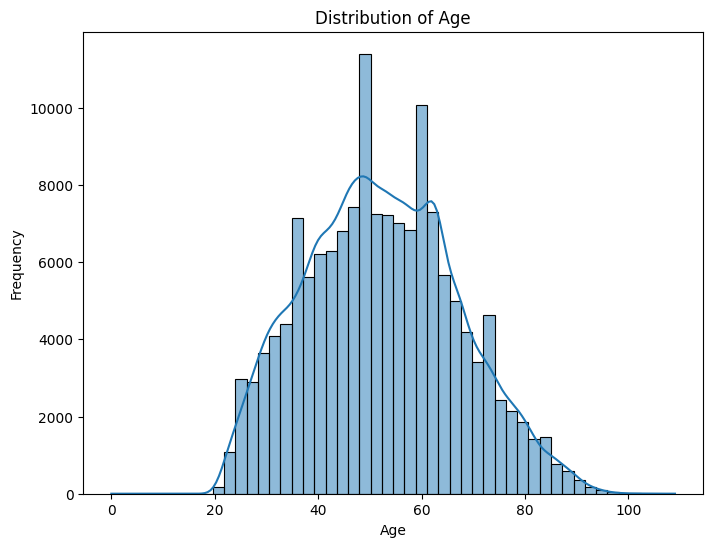

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(data = df, x = "age", bins = 50, kde = True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Chart 3 - Monthly Distribution


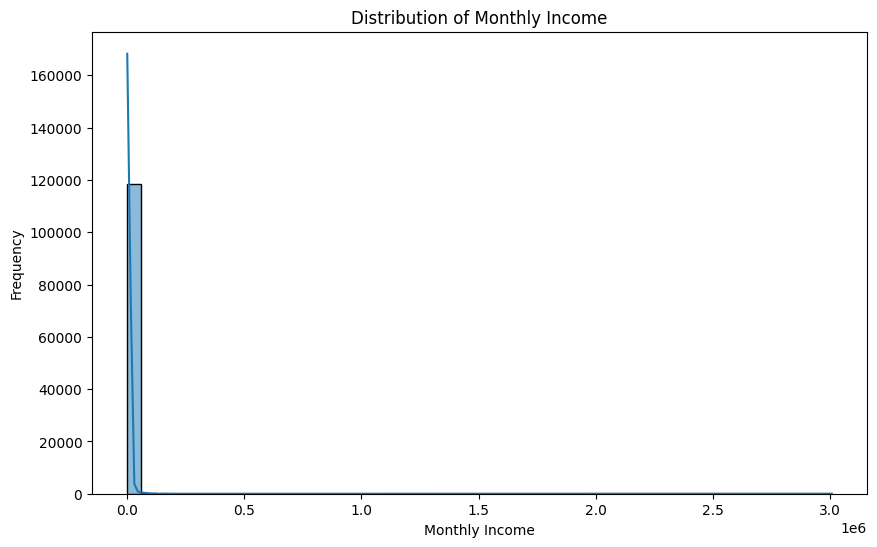

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(data = df, x = "MonthlyIncome", bins = 50, kde = True)
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

### Finding — Monthly Income Outliers
- X axis stretches to 3,000,000 — extreme outliers present
- Almost all borrowers compressed into first bar
- Chart proves outlier treatment is essential before modelling
- Next chart shows distribution filtered below 20,000 for clarity

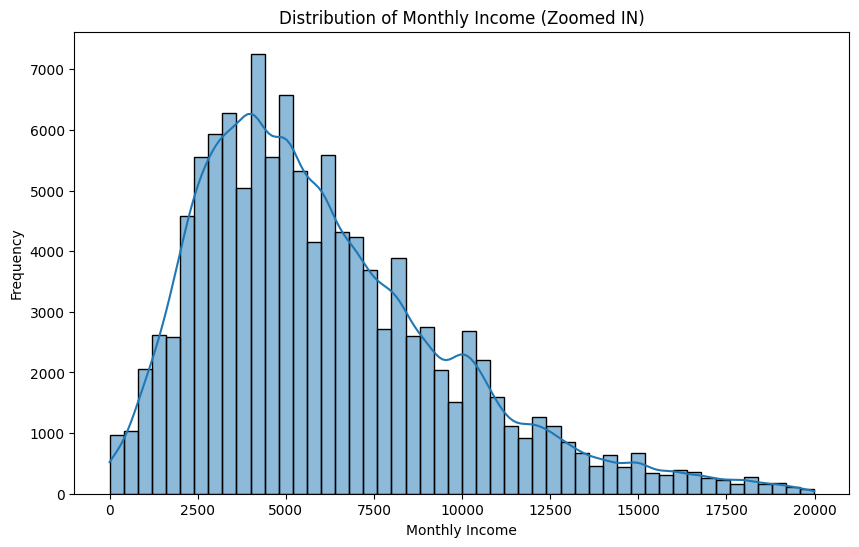

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(data = df[df["MonthlyIncome"] < 20000], x = "MonthlyIncome", bins = 50, kde = True)
plt.title("Distribution of Monthly Income (Zoomed IN)")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

### Finding — Monthly Income Real Distribution
- Filtered below 20,000 to exclude extreme outliers
- Distribution is right skewed — majority earn between 2,000 and 8,000
- Peak income around 4,000-5,000 per month
- 20,000 cutoff captures 95%+ of real data
- Extreme outliers above 20,000 need capping during preprocessing

### Chart 4 — DebtRatio Distribution and Outliers
Boxplot to visualize the extreme outliers in DebtRatio.
Normal DebtRatio should be between 0 and 1.
Values above 1 indicate debt payments exceeding monthly income.

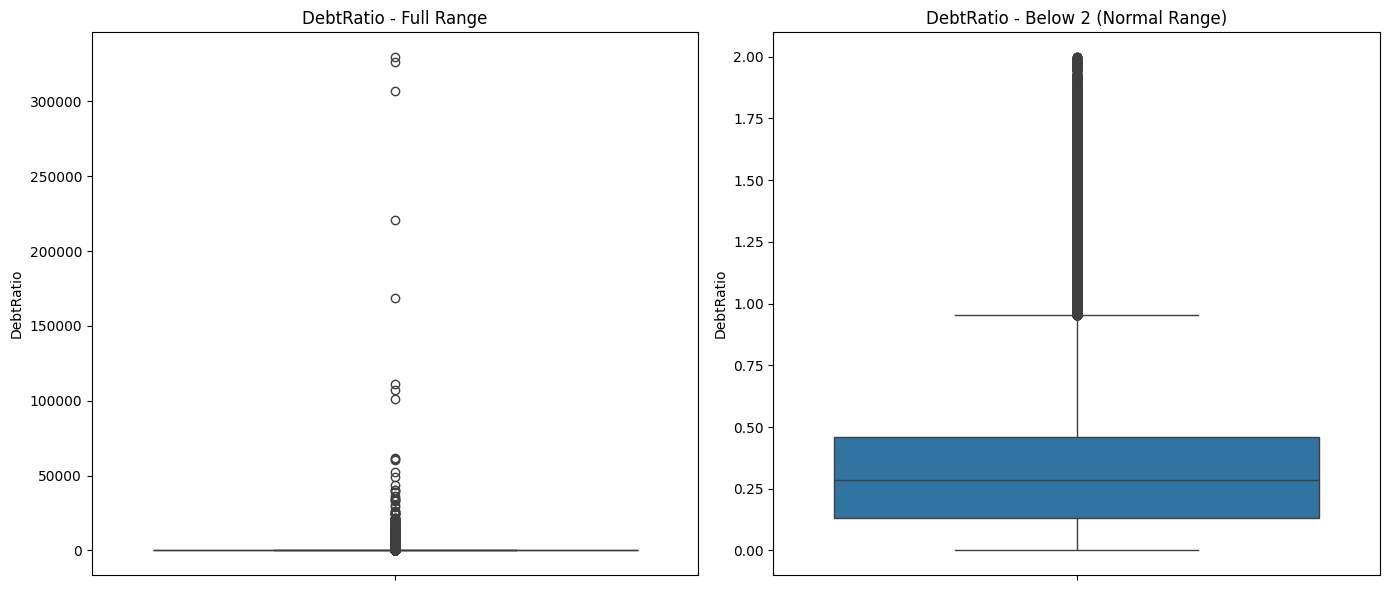

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(data = df, y = "DebtRatio", ax = ax1)
ax1.set_title("DebtRatio - Full Range")

sns.boxplot(data = df[df["DebtRatio"] < 2], y = "DebtRatio", ax = ax2)
ax2.set_title("DebtRatio - Below 2 (Normal Range)")

plt.tight_layout()
plt.show()

### Finding — DebtRatio Outliers
- Left chart: extreme outliers up to 329,664 confirmed visually
- Normal DebtRatio box is invisible in full range chart
- Right chart: normal range shows median around 0.30
- 35,137 rows above 1 need capping during preprocessing
- Will cap DebtRatio at 95th percentile value during Phase 3

### Chart 5 — Correlation Heatmap
Visualizing relationships between all columns.
Helps identify which features are most predictive of default
and which columns are highly correlated with each other.

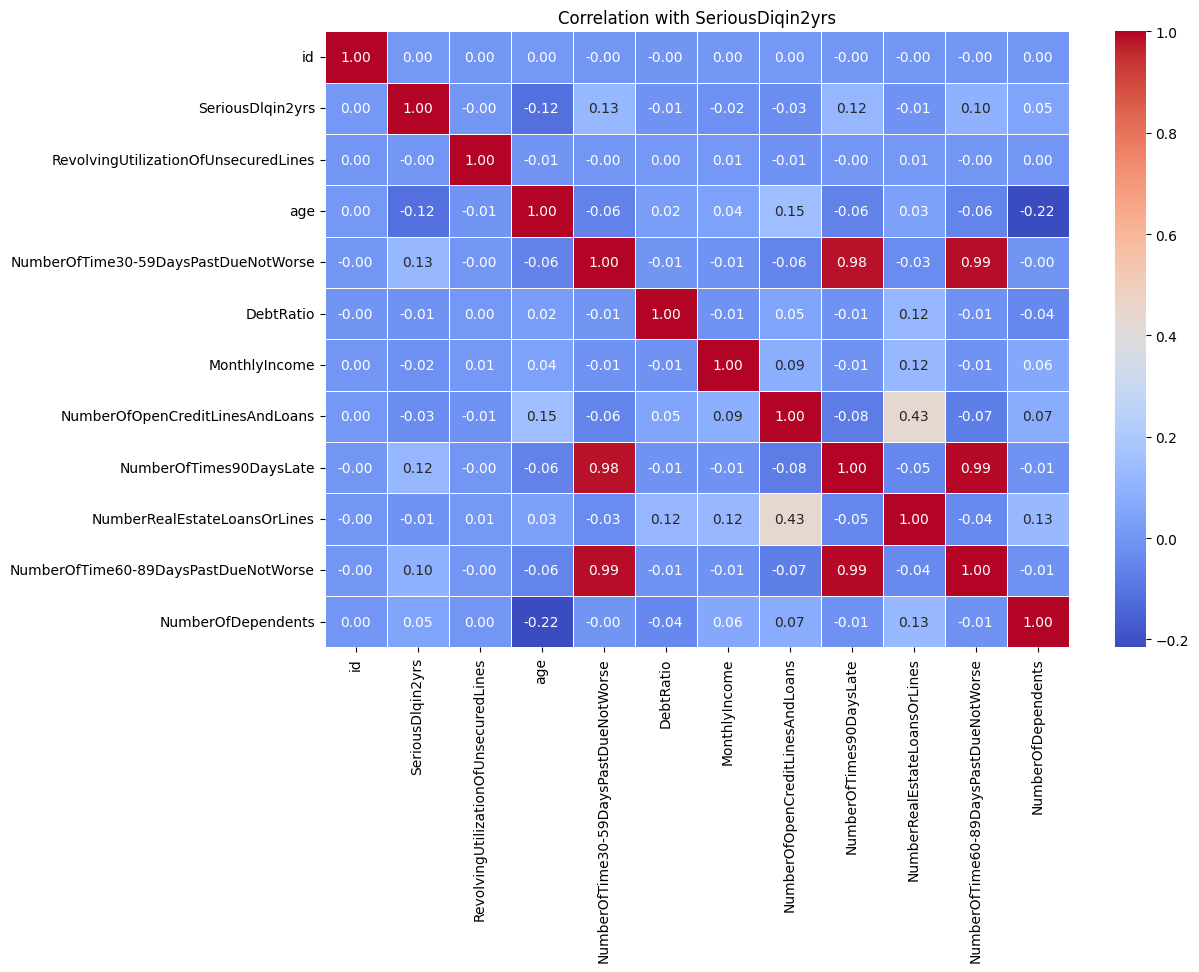

In [18]:
plt.figure(figsize=(12,8))
correlation_matrix = df.corr(numeric_only= True)
sns.heatmap(correlation_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', linewidths=0.5)
plt.title("Correlation with SeriousDiqin2yrs")
plt.show()

### Finding — Correlation Heatmap

#### Target Variable Correlations
- Late payment columns are strongest predictors of default
- Age is negatively correlated — older borrowers default less
- RevolvingUtilization surprisingly weak predictor

#### Critical Multicollinearity Found
- NumberOfTime30-59, 60-89, and 90DaysLate are 0.98-0.99 correlated
- These three columns carry almost identical information
- Action: consider dropping two of three during feature engineering

#### Other Notable Correlations
- NumberOfOpenCreditLines vs NumberRealEstateLoans → 0.43
- Age vs NumberOfDependents → -0.22 (older people have fewer dependents)